## import packages

In [8]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import pandas as pd # for creation of data frames
import numpy as np #
import pyls # PLS: behavioral and mean-centered
import seaborn as sns
import nibabel as nib # for loading niftis etc. as arrays
import matplotlib.pyplot as plt # for plotting data
#the output of plotting commands is displayed inline, directly below the code cell that produced it
%matplotlib inline 
import os,glob
from nilearn import plotting, input_data, image #for plotting & working with niftis

import pathlib

###################### update path!! #####################################
base_path = 'DATAPATH' 
script_path = 'SCRIPT_PATH' 
##########################################################################


### define FSL directories ######################################################
os.environ["FSLDIR"]='/usr/share/fsl/5.0'
os.environ["FSLOUTPUTTYPE"]='NIFTI_GZ'
os.environ["FSLTCLSH"]='/usr/bin/tclsh'
os.environ["FSLWISH"]='/usr/bin/wish'
os.environ["FSLMULTIFILEQUIT"]="True"
os.environ["LD_LIBRARY_PATH"]='/usr/share/fsl/5.0:/usr/lib/fsl/5.0'


#define ANTS directories
os.environ["ANTSPATH"] = '/opt/ants/bin'
os.environ["PATH"] = f'{os.environ["ANTSPATH"]}:{os.environ["PATH"]}'
if "LD_LIBRARY_PATH" in os.environ:
    os.environ["LD_LIBRARY_PATH"] = f'/opt/ants/lib:{os.environ["LD_LIBRARY_PATH"]}'
else:
    os.environ["LD_LIBRARY_PATH"] = '/opt/ants/lib'
#################################################################################

## define variables (please check!!)

In [9]:
data_dir = base_path + '/data'
derivatives_dir = data_dir + '/derivatives'
results_dir = data_dir + '/results'
raid_path = '/RAID1/jupytertmp/quantification/'
MNI_2mm_brain = derivatives_dir + '/MNI152_T1_2mm_brain.nii.gz'
GM_SNR_mask = os.path.join(derivatives_dir, 'N16_space-MNI152_SNR_YEO_CBV_mask.nii.gz')

sids_overlap = [1, 4, 7, 10, 11, 14, 15, 16, 17, 18, 19, 10] ## N=12, These subjects have both CMRglc and CMRO2
sids=[ 1, 2,  4, 7, 10,11,14, 15, 16, 17, 18, 19, 20 ] ##N=13, only non-pilot data, but including 10!
sids_cmrglc =[ 1, 3,4, 7, 9,10,11, 13,14, 15, 16, 17, 18, 19, 20 ] ## N=15

conds = [ 'open', 'checker']

sns.set_style("whitegrid")

coords=(-15, 0, 15, 30, 45, 60, 75, 90)


## median parameter maps across subjects in rest condition, MNI space

sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020


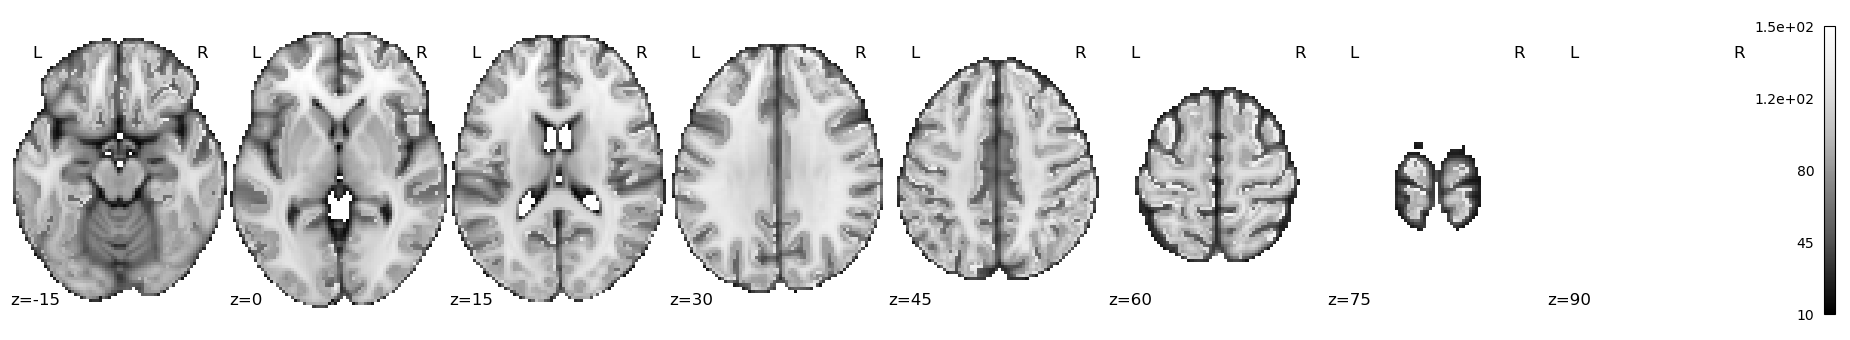

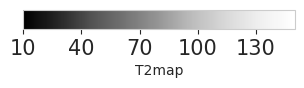

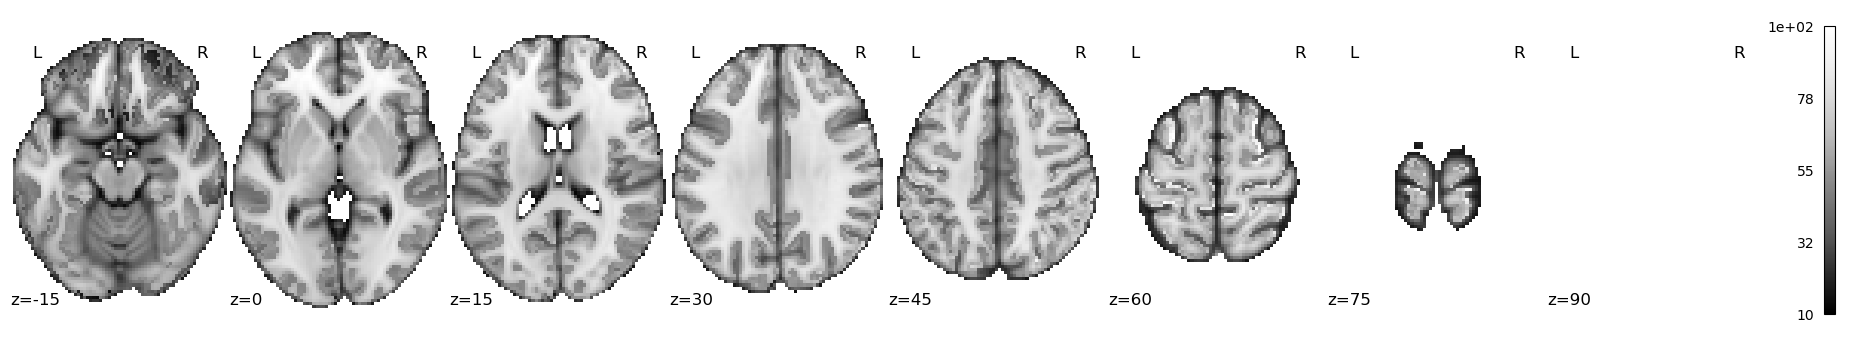

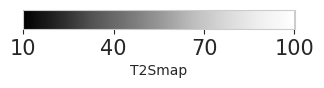

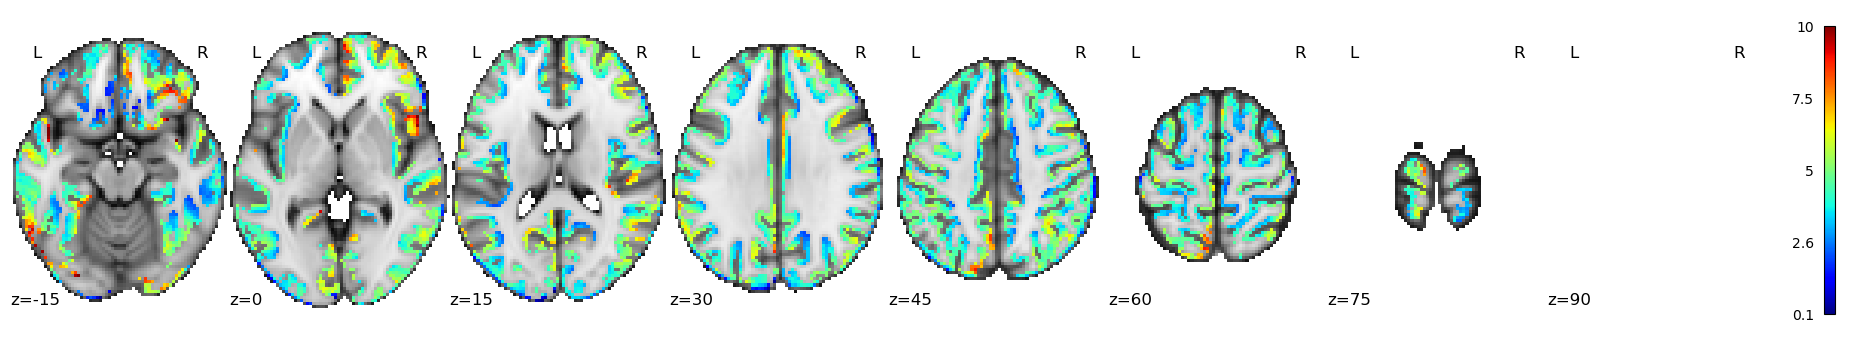

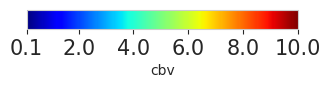

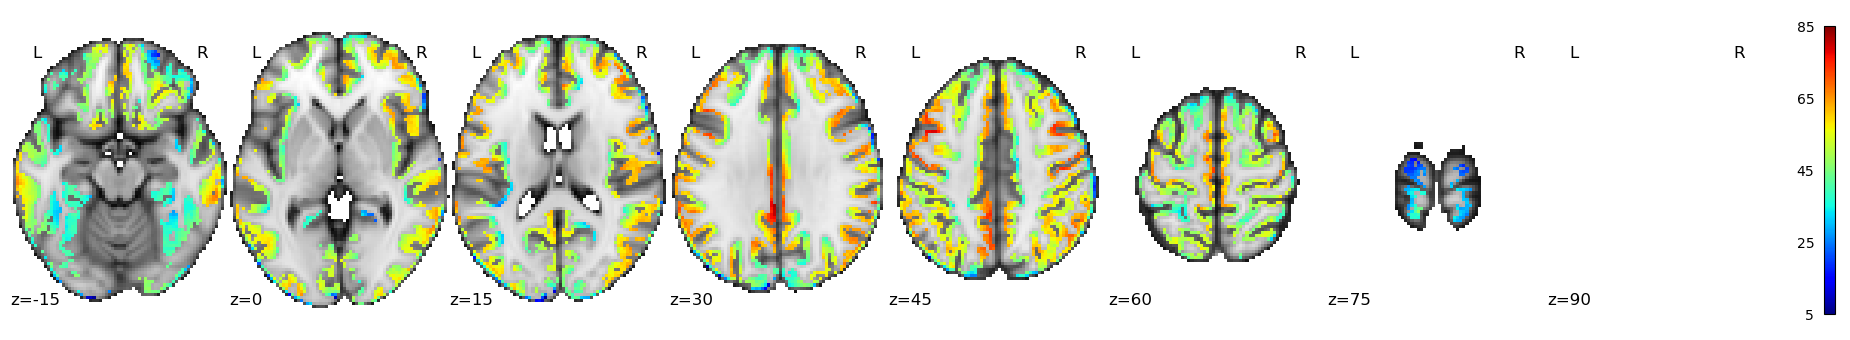

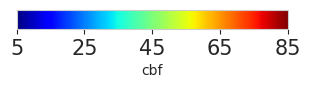

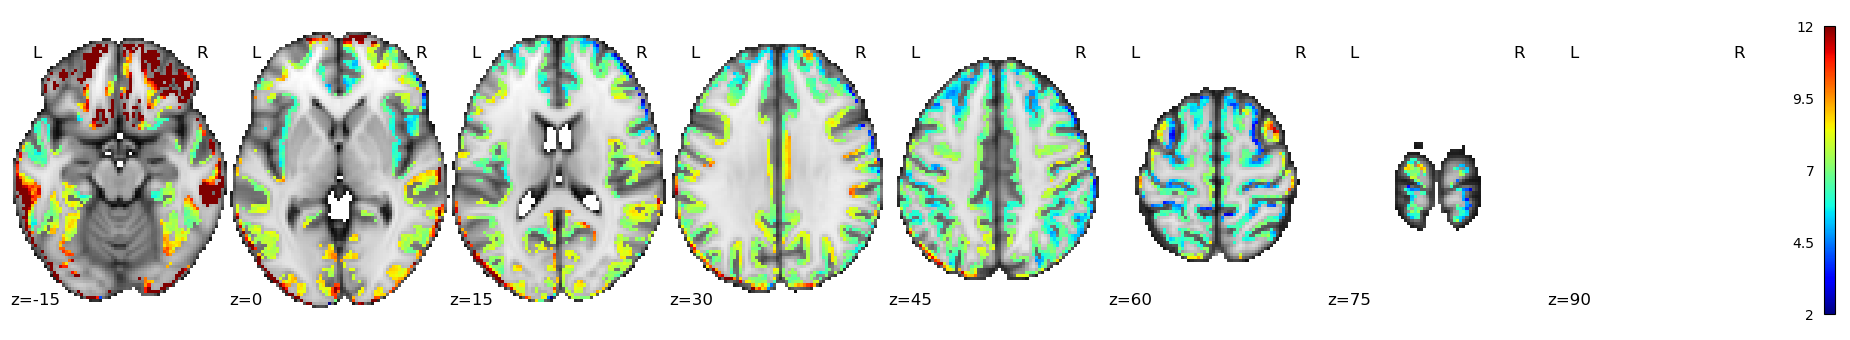

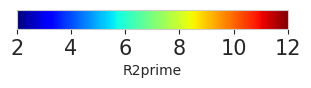

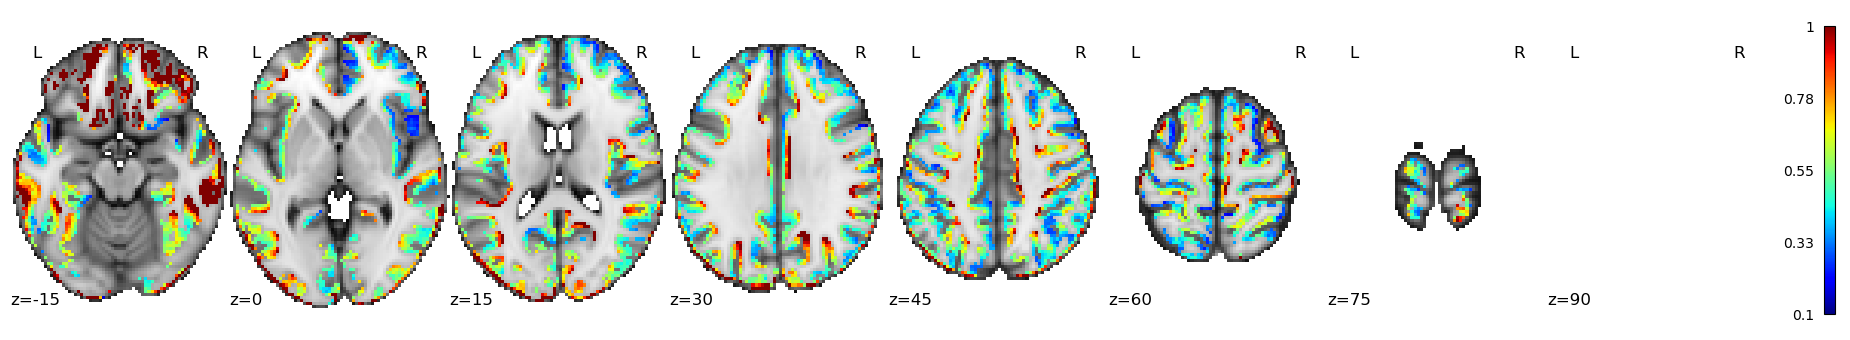

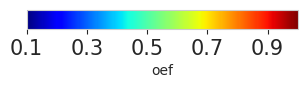

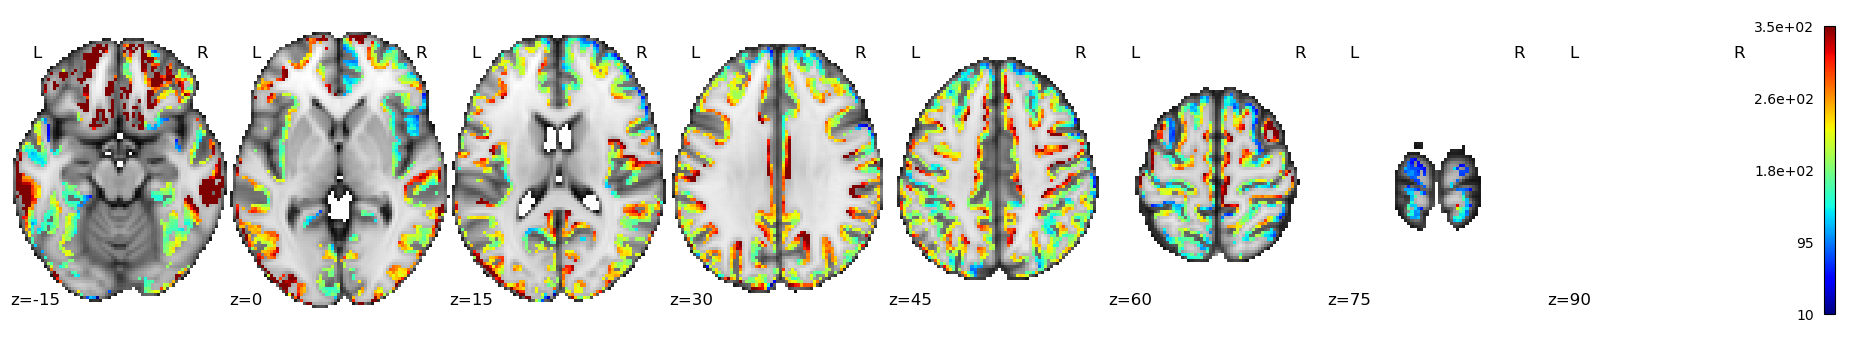

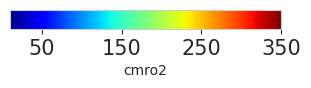

In [17]:
import matplotlib as mpl

cond='open'

parameters=['T2map', 'T2Smap', 'cbv', 'cbf', 'R2prime', 'oef', 'cmro2']
#parameters=['R2prime', 'oef', 'cmro2']

Br_MNI = nib.load(MNI_2mm_brain)

for par in parameters:
    #par_map = np.zeros((len(sids), len_mask))
    par_map = np.zeros(shape=(91,109,91,len(sids))) #shape = MNI, 4D = length(sids)
    for i, ID in enumerate(sids): #loop over subjects
        sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sid)
        sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        
        sub_dir = os.path.join(data_dir, sub)

        dir_deriv = os.path.join(derivatives_dir, sub)
        
            ## load parameter map
        if par != 'T2map' and par != 'cmro2':
                    par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-MNI152_'+ par +'.nii.gz')
        if par == 'T2map':
                    par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_space-MNI152_'+ par +'.nii.gz')
        if par == 'cmro2' and cond != 'checker':
                    par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-MNI152_'+ par +'.nii.gz')
        if par == 'cmro2' and cond == 'checker':
                    par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-MNI152_desc-30perc_'+ par +'.nii.gz')
        if par == 'cmrglc': 
            #par_nii = os.path.join(dir_deriv, 'fpet', sub + '_task-' +cond+'_space-MNI152_run-average_'+par+'.nii.gz')
            par_nii = os.path.join(dir_deriv, 'fpet', sub + '_glm_task-'+cond+'_space-MNI152_cmrglc.nii.gz')
        if par == 'func':
            par_nii =  os.path.join(dir_deriv, 'func', sub + '_task-'+cond+'_space-MNI152_filtered_func.nii.gz')


        par_values = np.array(nib.load(par_nii).dataobj)
        #par_map[i, :] = masker.fit_transform(par_nii)
        par_map[:, :, :, i] = par_values
            

    ## median per voxel, across subjects
    par_map_median = np.nanmedian(par_map, axis=3)
    
    ##turn into nifti
    par_map_nii = nib.Nifti1Image(par_map_median, affine=Br_MNI.affine)
    ##save nifti
    nib.save(par_map_nii, results_dir+ '/N' + str(len(sids)) + '_cond-'+cond + '_median_'+par+'.nii.gz')
    par_map_nifti = results_dir+ '/N' + str(len(sids)) + '_cond-'+cond + '_median_'+par+'.nii.gz'
    
    ##GM-mask
    par_map_nifti_GM = results_dir+ '/N' + str(len(sids)) + '_cond-'+cond + '_median_'+par+'_GM.nii.gz'
    ! fslmaths {par_map_nifti} -mas {GM_SNR_mask} {par_map_nifti_GM}
    
    ## plot nifti
    if par == 'T2map':
        min_thr=10
        max_thr= 150
        colormap= 'Greys_r'
        thr=10
        bound = [10, 40, 70, 100, 130]
    if par == 'T2Smap':
        min_thr=10
        max_thr= 100
        colormap= 'Greys_r'
        thr=10
        bound = [10, 40, 70, 100]
    if par == 'cbf':
        min_thr=5
        max_thr= 85
        colormap= 'jet'
        thr=5    
        bound = [5, 25, 45, 65, 85]
    if par == 'cbv':
        min_thr=0.1
        max_thr= 10
        colormap= 'jet'
        thr=0.1
        bound = [0.1, 2, 4, 6, 8, 10]
    if par == 'R2prime':
        min_thr=2
        max_thr= 12
        colormap= 'jet'
        thr=2
        bound = [2, 4, 6, 8, 10, 12]
    if par == 'oef':
        min_thr=0.1
        max_thr= 1
        colormap= 'jet'
        thr=0.1
        bound = [0.1, 0.3, 0.5, 0.7, 0.9]
    if par == 'cmro2':
        min_thr=10
        max_thr= 350
        colormap= 'jet'
        thr=10
        bound = [50,150, 250,350]
    if par == 'cmrglc':
        min_thr=10
        max_thr= 50
        colormap= 'jet'
        thr=10
        bound = [10,20, 30,40, 50]
        
    ## plot median image
    #fig, ax = plt.subplots(figsize=(3.5, 0.5))
    #plotting.plot_img(par_map_nii, threshold=thr, display_mode='z', vmin=min_thr, vmax=max_thr, cmap=colormap, colorbar=True, cut_coords=coords)
    fig = plotting.plot_img(par_map_nifti_GM, bg_img = MNI_2mm_brain, threshold=thr, display_mode='z', vmin=min_thr, vmax=max_thr, cmap=colormap, colorbar=True, cut_coords=coords)
    fig.savefig(results_dir+ '/' + par + '_median.png', dpi=300)
    
    ## plot colorbar separately
    ## draw stand-alone colourbar
    fig, ax = plt.subplots(figsize=(3.5, 0.5))
    fig.subplots_adjust(bottom=0.5)

    #cmap = mpl.cm.Greys_r
    bounds = bound
    norm = mpl.colors.Normalize(vmin=min_thr, vmax=max_thr)

    cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap), 
                 cax=ax, ticks=bounds, orientation='horizontal', label=par)
    cbar.ax.tick_params(labelsize=15)
    plt.tight_layout()
    
    fig.figure.savefig(results_dir + '/' + par + '_colorbar.png', format='png', dpi=300)
    

sub-fp001
sub-fp003
sub-fp004
sub-fp007
sub-fp009
sub-fp010
sub-fp011
sub-fp013
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020


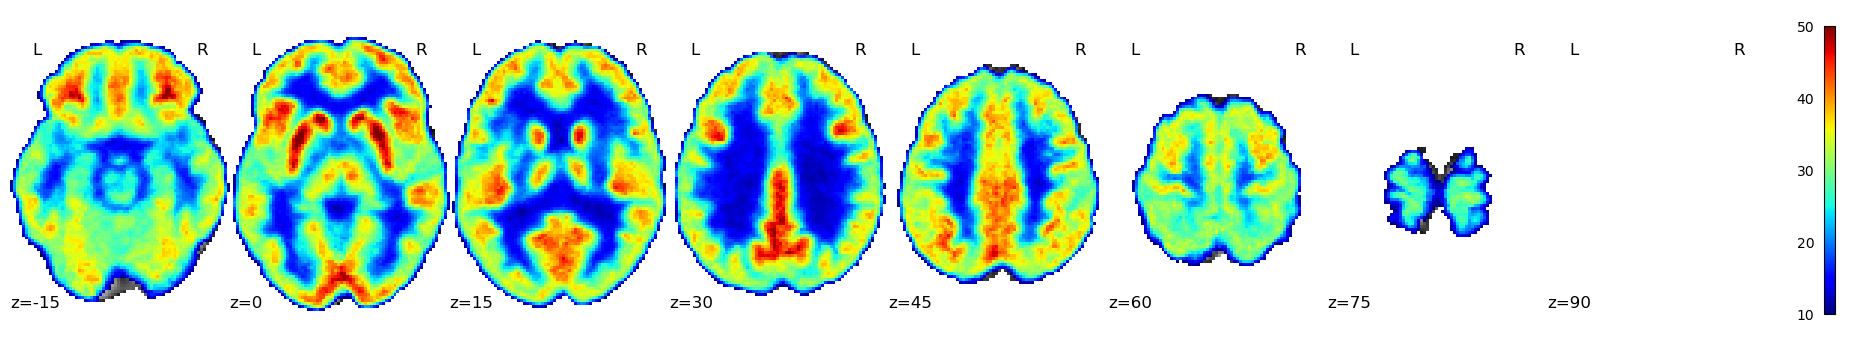

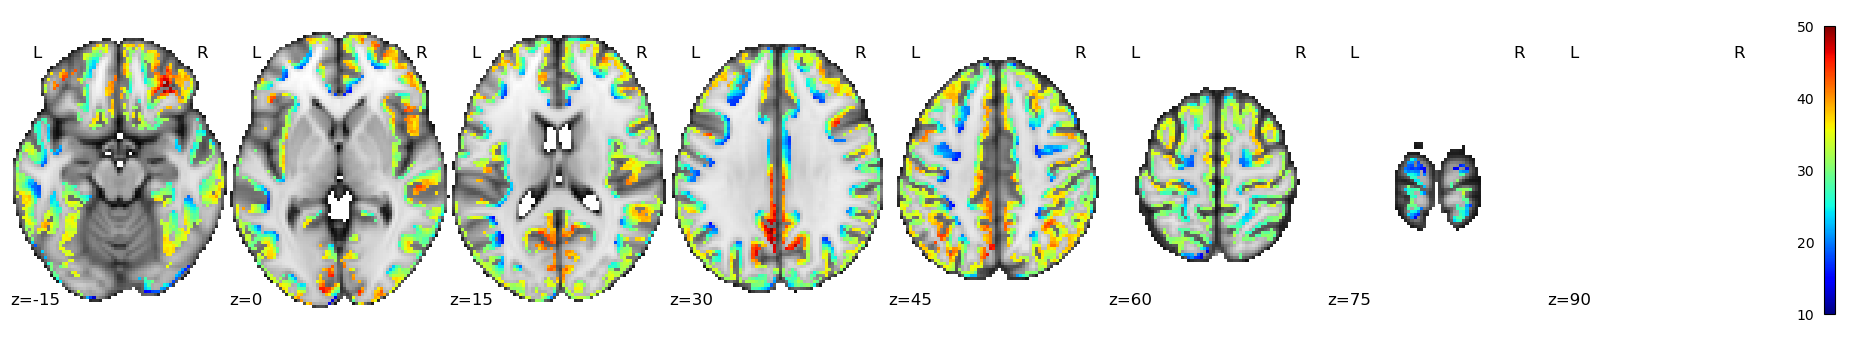

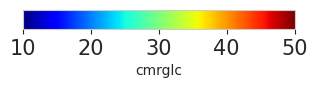

In [21]:
##CMRglc
import matplotlib as mpl

conds=['open', 'checker']
conds=['open']

parameters=['cmrglc']
MNI_2mm_brain = derivatives_dir + '/MNI152_T1_2mm_brain.nii.gz'

#! flirt -in {MNI_1mm} -ref {MNI_1mm} -applyisoxfm 2 -out {MNI_2mm} 
#! bet2 {MNI_2mm} {MNI_2mm_brain} 

Br_MNI = nib.load(MNI_2mm_brain)

for par in parameters:
    #par_map = np.zeros((len(sids), len_mask))
    par_map = np.zeros(shape=(91,109,91,len(sids_cmrglc))) #shape = MNI, 4D = length(sids)
    
    for cond in conds:
        for i, ID in enumerate(sids_cmrglc): #loop over subjects
            sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
            print(sid)
            sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
            subid = "sub-{:03d}".format(ID) # subject id, eg 'p021'
            
            sub_dir = os.path.join(data_dir, sub)

            dir_deriv = os.path.join(derivatives_dir, sub)

            ## load parameter map
            par_nii = os.path.join(dir_deriv, 'fpet', sub+ '_quant-cmrglc_task-' +cond+'_res-2_space-MNI6th.nii.gz')

            par_values = np.array(nib.load(par_nii).dataobj)
            #par_map[i, :] = masker.fit_transform(par_nii)
            par_map[:, :, :, i] = par_values


        ## median per voxel, across subjects
        par_map_median = np.nanmedian(par_map, axis=3)

        ##turn into nifti
        par_map_nii = nib.Nifti1Image(par_map_median, affine=Br_MNI.affine)
        ##save nifti
        nib.save(par_map_nii, results_dir+ '/N' + str(len(sids_cmrglc)) + '_cond-'+cond + '_median_'+par+'.nii.gz')
        par_map_nii = results_dir+ '/N' + str(len(sids_cmrglc)) + '_cond-'+cond + '_median_'+par+'.nii.gz'
        
        ##GM-mask
        par_map_nifti_GM = results_dir+ '/N' + str(len(sids_cmrglc)) + '_cond-'+cond + '_median_'+par+'_GM.nii.gz'
        ! fslmaths {par_map_nii} -mas {GM_SNR_mask} {par_map_nifti_GM}
    
        ## plot nifti
        if par == 'cmrglc':
            min_thr=10
            max_thr= 50
            colormap= 'jet'
            thr=10
            bound = [10,20, 30,40, 50]

        ## plot median image
        #fig, ax = plt.subplots(figsize=(3.5, 0.5))
        fig = plotting.plot_img(par_map_nii, bg_img=MNI_2mm_brain, threshold=thr, display_mode='z', vmin=min_thr, vmax=max_thr, cmap=colormap, colorbar=True, cut_coords=coords)
        fig.savefig(results_dir+ '/' + par + '_median.png', dpi=300)
        fig = plotting.plot_img(par_map_nifti_GM, bg_img=MNI_2mm_brain, threshold=thr, display_mode='z', vmin=min_thr, vmax=max_thr, cmap=colormap, colorbar=True, cut_coords=coords)
        fig.savefig(results_dir+ '/' + par + '_median_GM.png', dpi=300)
    
        ## plot colorbar separately
        ## draw stand-alone colourbar
        fig, ax = plt.subplots(figsize=(3.5, 0.5))
        fig.subplots_adjust(bottom=0.5)
    
        #cmap = mpl.cm.Greys_r
        bounds = bound
        norm = mpl.colors.Normalize(vmin=min_thr, vmax=max_thr)
    
        cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap), 
                     cax=ax, ticks=bounds, orientation='horizontal', label=par)
        cbar.ax.tick_params(labelsize=15)
        plt.tight_layout()
        
        fig.figure.savefig(results_dir + '/' + par + '_colorbar.png', format='png', dpi=300)
    

## create boxplots with median subject values, native space (only rest condition)

sub-fp001
T2map sub-fp001: 97.97821774249633
sub-fp002
T2map sub-fp002: 98.7647069056899
sub-fp004
T2map sub-fp004: 95.98938230182087
sub-fp007
T2map sub-fp007: 99.2950126214601
sub-fp010
T2map sub-fp010: 103.1802254731481
sub-fp011
T2map sub-fp011: 98.16116565817816
sub-fp014
T2map sub-fp014: 99.35449911552078
sub-fp015
T2map sub-fp015: 99.07445378427327
sub-fp016
T2map sub-fp016: 97.9726190236531
sub-fp017
T2map sub-fp017: 99.38167650308796
sub-fp018
T2map sub-fp018: 97.8531565903503
sub-fp019
T2map sub-fp019: 99.92592512972371
sub-fp020
T2map sub-fp020: 97.26976727470037
median = T2map 98.7647069056899
iqr = T2map 1.3818800918676857


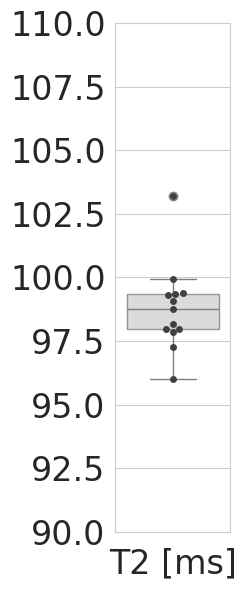

sub-fp001
T2Smap sub-fp001: 56.711404791366455
sub-fp002
T2Smap sub-fp002: 59.91712961643447
sub-fp004
T2Smap sub-fp004: 57.3376857029383
sub-fp007
T2Smap sub-fp007: 58.567096192845966
sub-fp010
T2Smap sub-fp010: 58.23730682648229
sub-fp011
T2Smap sub-fp011: 58.5560892655311
sub-fp014
T2Smap sub-fp014: 60.78702940690171
sub-fp015
T2Smap sub-fp015: 59.28659770977634
sub-fp016
T2Smap sub-fp016: 59.07676323316207
sub-fp017
T2Smap sub-fp017: 60.0067298142782
sub-fp018
T2Smap sub-fp018: 59.43881389021777
sub-fp019
T2Smap sub-fp019: 62.55318801486619
sub-fp020
T2Smap sub-fp020: 58.12943498300723
median = T2Smap 59.07676323316207
iqr = T2Smap 1.6798227899521834


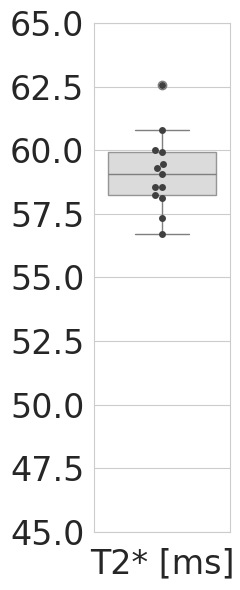

sub-fp001
cbv sub-fp001: 5.278837
sub-fp002
cbv sub-fp002: 5.0453243
sub-fp004
cbv sub-fp004: nan
sub-fp007
cbv sub-fp007: nan
sub-fp010
cbv sub-fp010: nan
sub-fp011
cbv sub-fp011: nan
sub-fp014
cbv sub-fp014: nan
sub-fp015
cbv sub-fp015: nan
sub-fp016
cbv sub-fp016: nan
sub-fp017
cbv sub-fp017: nan
sub-fp018
cbv sub-fp018: nan
sub-fp019
cbv sub-fp019: nan
sub-fp020
cbv sub-fp020: nan
median = cbv 5.162080764770508
iqr = cbv 0.11675643920898438


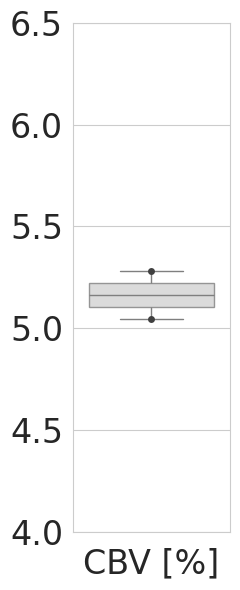

sub-fp001
cbf sub-fp001: 52.15307544458803
sub-fp002
cbf sub-fp002: 50.72779062709201
sub-fp004
cbf sub-fp004: 52.51396268866909
sub-fp007
cbf sub-fp007: 43.09466367532827
sub-fp010
cbf sub-fp010: 47.32292467688102
sub-fp011
cbf sub-fp011: 54.17119752460311
sub-fp014
cbf sub-fp014: 59.49986002429484
sub-fp015
cbf sub-fp015: 43.05000570881551
sub-fp016
cbf sub-fp016: 46.80094431225259
sub-fp017
cbf sub-fp017: 47.98020084540078
sub-fp018
cbf sub-fp018: 56.923584872347696
sub-fp019
cbf sub-fp019: 66.44121640584528
sub-fp020
cbf sub-fp020: 72.98865653319787
median = cbf 52.15307544458803
iqr = cbf 9.600660195466673


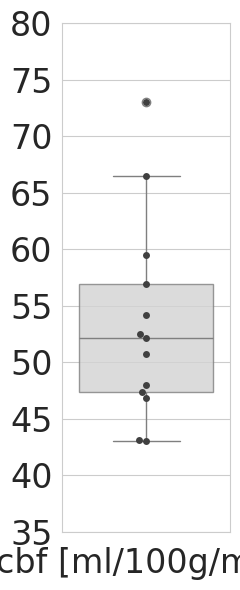

sub-fp001
R2prime sub-fp001: 8.20186713199411
sub-fp002
R2prime sub-fp002: 6.695104629144546
sub-fp004
R2prime sub-fp004: 7.451309269865055
sub-fp007
R2prime sub-fp007: 7.3383997594957355
sub-fp010
R2prime sub-fp010: 7.194110175817455
sub-fp011
R2prime sub-fp011: 7.106377496481912
sub-fp014
R2prime sub-fp014: 6.77405169216826
sub-fp015
R2prime sub-fp015: 6.975996333299956
sub-fp016
R2prime sub-fp016: 6.953069628362072
sub-fp017
R2prime sub-fp017: 6.799991665133925
sub-fp018
R2prime sub-fp018: 6.822324221360341
sub-fp019
R2prime sub-fp019: 6.340756034600249
sub-fp020
R2prime sub-fp020: 7.368833906991554
median = R2prime 6.975996333299956
iqr = R2prime 0.5384080943618104


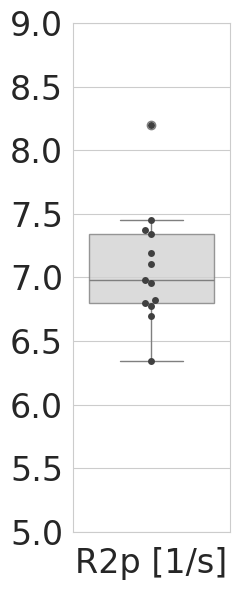

sub-fp001
oef sub-fp001: 0.550677939218917
sub-fp002
oef sub-fp002: 0.4844768158942589
sub-fp004
oef sub-fp004: 0.46831834405972284
sub-fp007
oef sub-fp007: 0.45958006000110796
sub-fp010
oef sub-fp010: 0.43946316758552634
sub-fp011
oef sub-fp011: 0.505867626511168
sub-fp014
oef sub-fp014: 0.4809660495864206
sub-fp015
oef sub-fp015: 0.44114136921292973
sub-fp016
oef sub-fp016: 0.45143501724167134
sub-fp017
oef sub-fp017: 0.3976996546109093
sub-fp018
oef sub-fp018: 0.42954724697624547
sub-fp019
oef sub-fp019: 0.3903668631023019
sub-fp020
oef sub-fp020: 0.4550550365720859
median = oef 0.4550550365720859
iqr = oef 0.04150288200089425


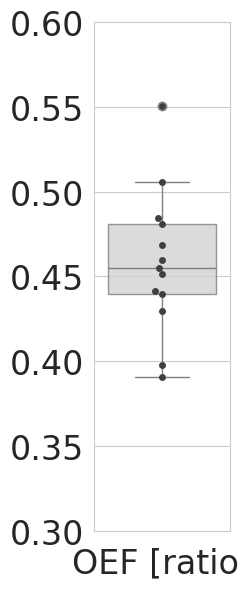

sub-fp001
cmro2 sub-fp001: 210.53616368849612
sub-fp002
cmro2 sub-fp002: 177.17609547375196
sub-fp004
cmro2 sub-fp004: 181.4998100010747
sub-fp007
cmro2 sub-fp007: 144.93699331366327
sub-fp010
cmro2 sub-fp010: 150.74640807435384
sub-fp011
cmro2 sub-fp011: 188.44028952077892
sub-fp014
cmro2 sub-fp014: 212.94290883826875
sub-fp015
cmro2 sub-fp015: 149.47589049120185
sub-fp016
cmro2 sub-fp016: 156.51841639600465
sub-fp017
cmro2 sub-fp017: 161.61396071336537
sub-fp018
cmro2 sub-fp018: 201.45799741617463
sub-fp019
cmro2 sub-fp019: 191.16291873263154
sub-fp020
cmro2 sub-fp020: 249.58845454094373
median = cmro2 181.4998100010747
iqr = cmro2 44.93958102016998


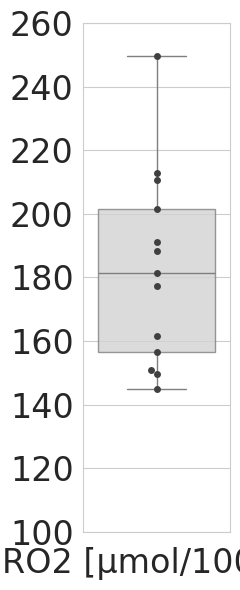

In [24]:
parameters=['T2map', 'T2Smap', 'cbv', 'cbf', 'R2prime', 'oef', 'cmro2']
#parameters=[ 'T2map']
fontsize=24
sns.set_style("whitegrid")
cond = 'open'
#GM_mask = os.path.join(derivatives_dir, 'MNI_GM_mask_0.5.nii.gz')
#GM_masker = input_data.NiftiMasker(mask_img=GM_mask)  ##mask = binary GM mask, path to mask 

## load thresholded native-space parameter maps for each condition, average across GM and plot as boxplots
for par in parameters:
    par_val = np.zeros((len(sids),1))
    par_val[:] = np.nan ##empy nan array
    for i, ID in enumerate(sids): #loop over subjects
        sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sid)
        sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'

        sub_dir = os.path.join(data_dir, sub)

        dir_deriv = os.path.join(derivatives_dir, sub)
        dir_anat_deriv = os.path.join(derivatives_dir, sub, 'anat')
        dir_func_deriv = os.path.join(derivatives_dir, sub, 'func')
        dir_perf_deriv = os.path.join(derivatives_dir, sub, 'perf')
        dir_qmri_deriv = os.path.join(derivatives_dir, sub, 'qmri')
            
        if par != 'T2map' and par != 'cmro2':
            par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-T2_'+ par +'_qBmasked.nii.gz')
        if par == 'T2map':
            par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_space-T2_'+ par +'_qBmasked.nii.gz')
        if par == 'cmro2' and cond != 'checker':
            par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-T2_'+ par +'_qBmasked.nii.gz')
        if par == 'cmro2' and cond == 'checker':
            par_nii =  os.path.join(dir_deriv, 'qmri', sub + '_task-'+cond+'_space-T2_desc-30perc_'+ par +'_qBmasked.nii.gz')                   
        #plotting.plot_img(par_nii, threshold=0.5, display_mode='z', cmap='jet', colorbar=True, cut_coords=coords)
        
        par_arr = np.array(nib.load(par_nii).dataobj)
        #par_arr = GM_masker.fit_transform(par_nii)
        subj_median = np.nanmedian(par_arr[par_arr>0]) ##only values bigger than zero
        subj_mean = np.nanmean(par_arr[par_arr>0]) ##only values bigger than zero
        
        print(par + ' ' + sid + ': ' + str(subj_mean))        
        par_val[i] = subj_mean           
            
    
    ## mean per subject, sd across subjects, across conditions, as in barplots      
    print('median = ' + par + ' ' + str(np.nanmedian(par_val.flatten())))
    q1 = np.nanpercentile(par_val.flatten(), 25)
    q3 = np.nanpercentile(par_val.flatten(), 75) 
    iqr = q3 - q1
    print('iqr = ' + par + ' '+ str(iqr))
    
    if par == 'T2map':
        label= 'T2 [ms]'
        vmin= 90
        vmax = 110
    if par == 'T2Smap':
        label= 'T2* [ms]'
        vmin=45
        vmax=65
    if par == 'cbv':
        label= 'CBV [%]'  
        vmin= 4
        vmax=6.5
    if par == 'cbf':
        label= 'cbf [ml/100g/min]'
        vmin= 35
        vmax=80
    if par == 'R2prime':
        label= 'R2p [1/s]'
        vmin=5
        vmax=9
    if par == 'oef':
        label= 'OEF [ratio]'
        vmin=0.3
        vmax = 0.6
    if par == 'cmro2':
        label= 'CMRO2 [μmol/100g/min]'
        vmin=100
        vmax=260
        
    ## plot boxplot
    fig, ax = plt.subplots(1, figsize=(2.5,6))
    sns.boxplot(y=par_val.flatten(), color='lightgray', boxprops=dict(alpha=.8), ax=ax, orient="v")
    sns.swarmplot(y=par_val.flatten(), color=".25", ax=ax, orient="v")
    ax.set_xlabel(label, fontsize=fontsize)
    ax.set_ylim(vmin, vmax)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()

    fig.figure.savefig(results_dir+ '/' + par + '_native_space_median.png', format='png', dpi=300)


sub-fp001
cmrglc sub-fp001: 40.322998
sub-fp002
cmrglc sub-fp002: 28.069883
sub-fp004
cmrglc sub-fp004: 41.39683
sub-fp007
cmrglc sub-fp007: 33.38357
sub-fp010
cmrglc sub-fp010: 27.453945
sub-fp011
cmrglc sub-fp011: 31.922644
sub-fp014
cmrglc sub-fp014: 25.768642
sub-fp015
cmrglc sub-fp015: 32.26054
sub-fp016
cmrglc sub-fp016: 31.449347
sub-fp017
cmrglc sub-fp017: 37.66814
sub-fp018
cmrglc sub-fp018: 34.06796
sub-fp019
cmrglc sub-fp019: 40.143814
sub-fp020
cmrglc sub-fp020: 43.110226
median = cmrglc 33.38357162475586
iqr = cmrglc 8.694467544555664


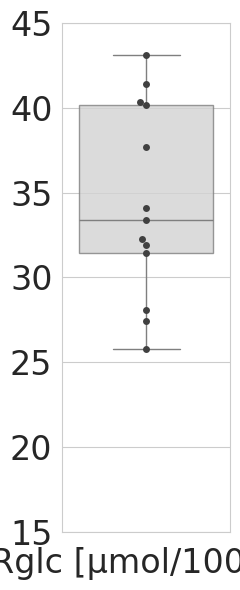

In [25]:
##different subjects for cmrglc!!

parameters=['cmrglc']
#parameters=[ 'T2Smap']
fontsize=24
sns.set_style("whitegrid")
cond = 'open'
GM_mask = os.path.join(derivatives_dir, 'MNI_GM_mask_0.5.nii.gz')
GM_masker = input_data.NiftiMasker(mask_img=GM_mask)  ##mask = binary GM mask, path to mask 

## load thresholded native-space parameter maps for each condition, average across GM and plot as boxplots
for par in parameters:
    par_val = np.zeros((len(sids),1))
    par_val[:] = np.nan ##empy nan array
    for i, ID in enumerate(sids): #loop over subjects
        sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sid)
        sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'

        sub_dir = os.path.join(data_dir, sub)

        dir_deriv = os.path.join(derivatives_dir, sub)
            
        par_nii =  os.path.join(dir_deriv, 'fpet', sub + '_glm_task-open_space-T2_'+par+'_qBmasked.nii.gz')
                   
        #plotting.plot_img(par_nii, threshold=0.5, display_mode='z', cmap='jet', colorbar=True, cut_coords=coords)
        
        par_arr = np.array(nib.load(par_nii).dataobj)
        #par_arr = GM_masker.fit_transform(par_nii)
        subj_median = np.nanmedian(par_arr[par_arr>0]) ##only values bigger than zero
        subj_mean = np.nanmean(par_arr[par_arr>0]) ##only values bigger than zero
        
        print(par + ' ' + sid + ': ' + str(subj_mean))        
        par_val[i] = subj_mean           
            
    
    ## mean per subject, sd across subjects, across conditions, as in barplots      
    print('median = ' + par + ' ' + str(np.nanmedian(par_val.flatten())))
    q1 = np.nanpercentile(par_val.flatten(), 25)
    q3 = np.nanpercentile(par_val.flatten(), 75) 
    iqr = q3 - q1
    print('iqr = ' + par + ' '+ str(iqr))
    
    
    if par == 'cmrglc':
        label= 'CMRglc [μmol/100g/min]'
        vmin=15
        vmax=45
        
    ## plot boxplot
    fig, ax = plt.subplots(1, figsize=(2.5,6))
    sns.boxplot(y=par_val.flatten(), color='lightgray', boxprops=dict(alpha=.8), ax=ax, orient="v")
    sns.swarmplot(y=par_val.flatten(), color=".25", ax=ax, orient="v")
    ax.set_xlabel(label, fontsize=fontsize)
    ax.set_ylim(vmin, vmax)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()

    fig.figure.savefig(results_dir+ '/' + par + '_native_space_median.png', format='png', dpi=300)


#### 